# Imports

In [8]:
import io
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import pandas as pd
from pathlib import Path

# DATA INLADEN 

In [9]:
DATA_DIR = Path("/Users/nachatissa/Desktop/SCHOOL/SEM2/Advanced AI/untitled folder/Advanced-AI/dataset/closed-open-eyes/data")

parquet_files = sorted(DATA_DIR.rglob("*.parquet"))
df = pd.concat([pd.read_parquet(p) for p in parquet_files], ignore_index=True)
df.columns = df.columns.str.replace("'", "")
print(f"✅ Dataset shape: {df.shape}")
print(df.head())

✅ Dataset shape: (126560, 5)
   Image_id      Left_eye_react     Right_eye_react        Label  \
0         0   [329, 219, 29, 9]  [230, 222, 49, 10]  closed_eyes   
1         1   [321, 202, 31, 9]  [221, 197, 46, 10]  closed_eyes   
2         2  [260, 187, 45, 10]   [166, 187, 39, 9]  closed_eyes   
3         3  [219, 235, 23, 15]  [141, 233, 41, 16]  closed_eyes   
4         4   [280, 223, 41, 8]   [204, 224, 30, 8]  closed_eyes   

                                          Image_data  
0  {'file': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x0...  
1  {'file': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x0...  
2  {'file': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x0...  
3  {'file': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x0...  
4  {'file': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x0...  


# Label map + test image cell


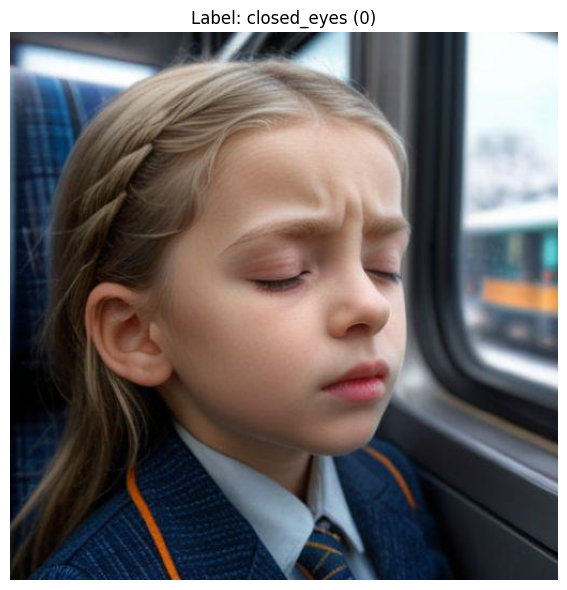

✅ Image toont correct


In [4]:
label_map = {"closed_eyes": 0, "open_eyes": 1}
df['Label_int'] = df['Label'].map(label_map)

sample = df.iloc[0]
image_bytes = sample["Image_data"]["file"]
img = Image.open(io.BytesIO(image_bytes)).convert("RGB")

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title(f"Label: {sample['Label']} ({label_map[sample['Label']]})")
plt.axis("off")
plt.tight_layout()
plt.show()
print("✅ Image toont correct")

# CACHING IMAGE RESIZE to make model training faster RUN ONLY ONCE 

In [10]:
CACHEDIR = Path("/Users/nachatissa/Desktop/SCHOOL/SEM2/Advanced AI/untitled folder/Advanced-AI/dataset/eyecache")
CACHEDIR.mkdir(parents=True, exist_ok=True)

rows = []
for i, row in df.iterrows():
    image_bytes = row["Image_data"]["file"]
    img = Image.open(io.BytesIO(image_bytes)).convert("RGB")
    img = img.resize((224, 224))
    
    outpath = CACHEDIR / f"{i}.jpg"
    img.save(outpath, quality=95)
    
    label_numeric = label_map.get(row["Label"], 0)
    rows.append({"path": str(outpath), "Label": label_numeric})

cached_df = pd.DataFrame(rows)
cached_df.to_csv("dataset_met_getallen.csv", index=False)
print(f"✅ {len(cached_df)} images gecached in {CACHEDIR}")

✅ 126560 images gecached in /Users/nachatissa/Desktop/SCHOOL/SEM2/Advanced AI/untitled folder/Advanced-AI/dataset/eyecache


# Simple dataset


In [13]:
class EyeDataset(Dataset):
    def __init__(self, dataframe):
        self.df = dataframe.reset_index(drop=True)
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        img = np.array(img, dtype=np.float32) / 255.0
        img = torch.tensor(img).permute(2, 0, 1)
        label = torch.tensor(row["Label"], dtype=torch.long)
        return img, label

print("✅ EyeDataset gedefinieerd")

✅ EyeDataset gedefinieerd


# Split and loaders

In [ ]:
train_df, val_df = train_test_split(cached_df, test_size=0.2, random_state=42, stratify=cached_df["Label"])

train_ds = EyeDataset(train_df)
val_ds = EyeDataset(val_df)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=32, num_workers=0, pin_memory=True)

print(f"✅ Train: {len(train_ds)}, Val: {len(val_ds)}")
print("✅ DataLoaders klaar - geen multiprocessing errors!")

# CNN CLASS

In [14]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )
    
    def forward(self, x):
        return self.model(x)

print("✅ SimpleCNN gedefinieerd")

✅ SimpleCNN gedefinieerd


# device training setup 

# TRAIN 

In [ ]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"✅ Using device: {device}")

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(10):  # Meer epochs voor betere acc
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        preds = outputs.argmax(1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()
    
    print(f"Epoch {epoch+1}/10, Loss: {running_loss/len(train_loader):.4f}, Acc: {correct/total:.4f}")

# VALIDATE

In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

print(f"✅ Final Validation Accuracy: {correct/total:.4f}")

MODEL OPSLAAN

In [ ]:
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'label_map': label_map
}, 'fatigue_model_complete.pth')

print("✅ Model opgeslagen als 'fatigue_model_complete.pth'")
print("Load later: checkpoint = torch.load('fatigue_model_complete.pth')")
print("model.load_state_dict(checkpoint['model_state_dict'])")

# FINE TUNING MET EIGEN FOTOS 

In [15]:


cached_csv = Path("dataset_met_getallen.csv")
if not cached_csv.exists():
    raise FileNotFoundError("❌ dataset_met_getallen.csv niet gevonden. Run eerst de grote caching cell.")

cached_df = pd.read_csv(cached_csv)
print(f"✅ cached_df geladen: {len(cached_df)}")

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"✅ Using device: {device}")


MY_DATA_DIR = Path("/Users/nachatissa/Desktop/SCHOOL/SEM2/Advanced AI/untitled folder/Advanced-AI/dataset/my_eye_finetune")
MY_CACHE_DIR = Path("/Users/nachatissa/Desktop/SCHOOL/SEM2/Advanced AI/untitled folder/Advanced-AI/dataset/my_eye_finetune_cache")
MY_CACHE_DIR.mkdir(parents=True, exist_ok=True)

label_map_finetune = {
    "closed": 0,
    "open": 1
}

rows_new = []
img_id = 0

for class_name in ["closed", "open"]:
    class_dir = MY_DATA_DIR / class_name

    if not class_dir.exists():
        print(f"⚠️ Map niet gevonden: {class_dir}")
        continue

    for img_path in sorted(class_dir.glob("*")):
        if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png", ".bmp", ".webp"]:
            continue

        try:
            img = Image.open(img_path).convert("RGB")
            img = img.resize((224, 224))

            out_path = MY_CACHE_DIR / f"ft_{img_id:04d}.jpg"
            img.save(out_path, quality=95)

            rows_new.append({
                "path": str(out_path),
                "Label": label_map_finetune[class_name]
            })
            img_id += 1

        except Exception as e:
            print(f"❌ Fout bij {img_path.name}: {e}")

my_df = pd.DataFrame(rows_new)
print(f"✅ Eigen finetune images gevonden: {len(my_df)}")

if len(my_df) == 0:
    raise ValueError("❌ Geen images gevonden in open/closed mappen.")

combined_df = pd.concat([cached_df, my_df], ignore_index=True)
print(f"✅ Totale dataset na toevoegen eigen images: {len(combined_df)}")

train_df_ft, val_df_ft = train_test_split(
    combined_df,
    test_size=0.2,
    random_state=42,
    stratify=combined_df["Label"]
)

train_ds_ft = EyeDataset(train_df_ft)
val_ds_ft = EyeDataset(val_df_ft)

train_loader_ft = DataLoader(train_ds_ft, batch_size=32, shuffle=True, num_workers=0, pin_memory=True)
val_loader_ft = DataLoader(val_ds_ft, batch_size=32, num_workers=0, pin_memory=True)

print(f"✅ Fine-tune Train: {len(train_ds_ft)}, Val: {len(val_ds_ft)}")

checkpoint_path = Path("fatigue_model_complete.pth")
if not checkpoint_path.exists():
    raise FileNotFoundError("❌ fatigue_model_complete.pth niet gevonden. Train/save eerst je basismodel.")

finetune_model = SimpleCNN().to(device)
checkpoint = torch.load(checkpoint_path, map_location=device)
finetune_model.load_state_dict(checkpoint["model_state_dict"])

print("✅ Bestaand model geladen voor fine-tuning")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(finetune_model.parameters(), lr=1e-4)

EPOCHS = 3

for epoch in range(EPOCHS):
    finetune_model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader_ft:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = finetune_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = outputs.argmax(1)
        total += labels.size(0)
        correct += (preds == labels).sum().item()

    train_acc = correct / total
    avg_loss = running_loss / len(train_loader_ft)

    finetune_model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader_ft:
            images, labels = images.to(device), labels.to(device)
            outputs = finetune_model(images)
            preds = outputs.argmax(1)
            val_total += labels.size(0)
            val_correct += (preds == labels).sum().item()

    val_acc = val_correct / val_total
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

torch.save({
    "model_state_dict": finetune_model.state_dict(),
    "label_map": {"closed_eyes": 0, "open_eyes": 1}
}, "fatigue_model_finetuned.pth")

print("✅ Fine-tuned model opgeslagen als 'fatigue_model_finetuned.pth'")

✅ cached_df geladen: 126560
✅ Using device: mps
✅ Eigen finetune images gevonden: 23
✅ Totale dataset na toevoegen eigen images: 126583
✅ Fine-tune Train: 101266, Val: 25317
✅ Bestaand model geladen voor fine-tuning


/Users/nachatissa/Desktop/SCHOOL/SEM2/Advanced AI/untitled folder/Advanced-AI/fatigue_venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/3 | Loss: 0.0049 | Train Acc: 0.9985 | Val Acc: 0.9932
Epoch 2/3 | Loss: 0.0029 | Train Acc: 0.9992 | Val Acc: 0.9934
Epoch 3/3 | Loss: 0.0027 | Train Acc: 0.9993 | Val Acc: 0.9937
✅ Fine-tuned model opgeslagen als 'fatigue_model_finetuned.pth'
